Name-Riya choudhary

Subject-Computer vision lab

CUID-CU24250251

**Experiment No. 7**

Motion Estimation using Optical Flow Algorithms in Video Sequences

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Step 2: Create a synthetic video with moving objects

VIDEO_PATH = "optical_flow_video.mp4"

FRAME_W = 400
FRAME_H = 300
NUM_FRAMES = 100
FPS = 20

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    VIDEO_PATH,
    fourcc,
    FPS,
    (FRAME_W, FRAME_H)
)

for i in range(NUM_FRAMES):

    frame = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

    # Moving circle
    x = 40 + int(i * 2.5)
    y = 80 + int(i * 0.8)

    cv2.circle(
        frame,
        (x, y),
        20,
        (0, 255, 255),
        -1
    )

    # Moving rectangle
    x2 = 20 + int(i * 2)

    cv2.rectangle(
        frame,
        (x2, 200),
        (x2 + 50, 240),
        (0, 255, 0),
        -1
    )

    writer.write(frame)

writer.release()

print("Synthetic video created successfully!")
print("Number of frames:", NUM_FRAMES)
print("Video FPS:", FPS)

Synthetic video created successfully!
Number of frames: 100
Video FPS: 20


First video frame read successfully!
Frame shape: (300, 400, 3)
Grayscale frame shape: (300, 400)


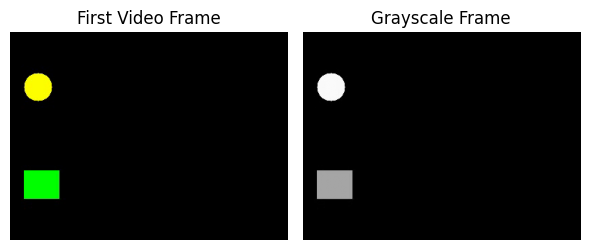

In [12]:
# Step 3: Read the first video frame and convert it to grayscale

cap = cv2.VideoCapture(VIDEO_PATH)

ret, first_frame = cap.read()

if not ret:
    raise RuntimeError("Could not read the video.")

first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

print("First video frame read successfully!")
print("Frame shape:", first_frame.shape)
print("Grayscale frame shape:", first_gray.shape)

# Display the first frame and grayscale frame
plt.figure(figsize=(6, 2.8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("First Video Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(first_gray, cmap="gray")
plt.title("Grayscale Frame")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Step 4: Lucas-Kanade Sparse Optical Flow

# Parameters for detecting good feature points
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# Parameters for Lucas-Kanade optical flow
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

# Detect feature points in the first frame
prev_points = cv2.goodFeaturesToTrack(
    first_gray,
    mask=None,
    **feature_params
)

print("Lucas-Kanade Optical Flow initialized successfully!")

if prev_points is not None:
    print("Number of feature points detected:", len(prev_points))
else:
    print("No feature points detected.")

Lucas-Kanade Optical Flow initialized successfully!
Number of feature points detected: 4


In [6]:
# Step 5: Calculate motion between two consecutive frames

# Read the next frame
ret, next_frame = cap.read()

if not ret:
    raise RuntimeError("Could not read the next video frame.")

next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)

# Calculate the new positions of the feature points
next_points, status, error = cv2.calcOpticalFlowPyrLK(
    first_gray,
    next_gray,
    prev_points,
    None,
    **lk_params
)

# Keep only successfully tracked points
good_new = next_points[status == 1]
good_old = prev_points[status == 1]

print("Lucas-Kanade motion calculated successfully!")
print("Points successfully tracked:", len(good_new))

# Display the old and new positions
for i, (new, old) in enumerate(zip(good_new, good_old)):
    new_x, new_y = new.ravel()
    old_x, old_y = old.ravel()

    print(
        f"Point {i+1}: "
        f"({old_x:.1f}, {old_y:.1f}) -> "
        f"({new_x:.1f}, {new_y:.1f})"
    )

Lucas-Kanade motion calculated successfully!
Points successfully tracked: 4
Point 1: (22.0, 202.0) -> (24.0, 202.0)
Point 2: (68.0, 202.0) -> (70.0, 202.0)
Point 3: (22.0, 238.0) -> (24.0, 238.0)
Point 4: (68.0, 238.0) -> (70.0, 238.0)


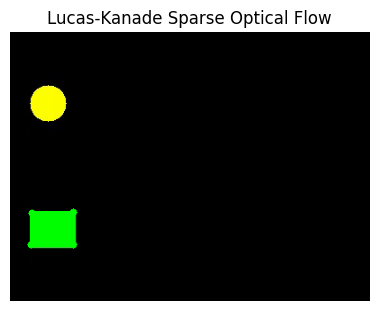

In [13]:
# Step 6: Visualize Lucas-Kanade motion vectors

output_lk = next_frame.copy()

for new, old in zip(good_new, good_old):
    new_x, new_y = new.ravel()
    old_x, old_y = old.ravel()

    # Draw motion line
    cv2.line(
        output_lk,
        (int(old_x), int(old_y)),
        (int(new_x), int(new_y)),
        (255, 0, 0),
        2
    )

    # Mark the new position
    cv2.circle(
        output_lk,
        (int(new_x), int(new_y)),
        4,
        (0, 255, 0),
        -1
    )

# Convert BGR to RGB for Matplotlib
output_lk_rgb = cv2.cvtColor(output_lk, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 3.5))
plt.imshow(output_lk_rgb)
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.show()

In [8]:
# Step 7: Farneback Dense Optical Flow

# Start again from the first frame
cap_fb = cv2.VideoCapture(VIDEO_PATH)

ret, frame1 = cap_fb.read()

if not ret:
    raise RuntimeError("Could not read the first frame.")

prev_gray_fb = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

# Read the second frame
ret, frame2 = cap_fb.read()

if not ret:
    raise RuntimeError("Could not read the second frame.")

gray_fb = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Calculate dense optical flow
t0 = time.perf_counter()

flow = cv2.calcOpticalFlowFarneback(
    prev_gray_fb,
    gray_fb,
    None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

fb_time = time.perf_counter() - t0

print("Farneback Dense Optical Flow calculated successfully!")
print("Flow shape:", flow.shape)
print(f"Calculation time: {fb_time * 1000:.3f} ms")

cap_fb.release()

Farneback Dense Optical Flow calculated successfully!
Flow shape: (300, 400, 2)
Calculation time: 69.082 ms


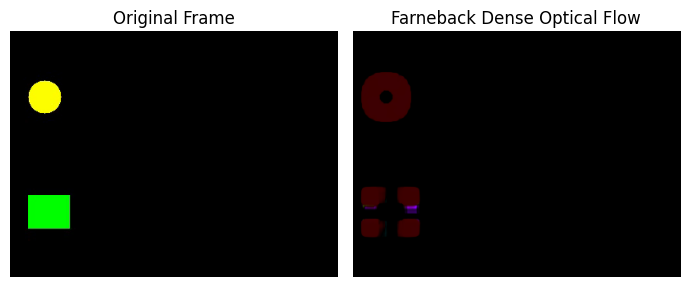

Average flow magnitude: 0.0917
Maximum flow magnitude: 8.3095


In [14]:
# Step 8: Visualize Farneback Dense Optical Flow

# Convert flow into magnitude and angle
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Create HSV image
hsv = np.zeros_like(frame1)

# Saturation is set to maximum
hsv[..., 1] = 255

# Direction of motion
hsv[..., 0] = angle * 180 / np.pi / 2

# Magnitude of motion
hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

# Convert HSV to BGR
dense_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Convert BGR to RGB for displaying with Matplotlib
dense_flow_rgb = cv2.cvtColor(dense_flow, cv2.COLOR_BGR2RGB)

# Display original frame and dense optical flow
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dense_flow_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Average flow magnitude: {np.mean(magnitude):.4f}")
print(f"Maximum flow magnitude: {np.max(magnitude):.4f}")

In [10]:
# Step 9: Compare Lucas-Kanade and Farneback Optical Flow

# Calculate Lucas-Kanade computation time again
t0 = time.perf_counter()

next_points, status, error = cv2.calcOpticalFlowPyrLK(
    first_gray,
    next_gray,
    prev_points,
    None,
    **lk_params
)

lk_time = time.perf_counter() - t0

# Number of successfully tracked points
tracked_points = np.sum(status == 1)

print("Lucas-Kanade vs Farneback Comparison")
print("-------------------------------------")

print(f"{'Property':25s} | {'Lucas-Kanade':25s} | {'Farneback':25s}")
print("-" * 80)

print(
    f"{'Type':25s} | "
    f"{'Sparse':25s} | "
    f"{'Dense':25s}"
)

print(
    f"{'Coverage':25s} | "
    f"{'Selected points':25s} | "
    f"{'Every pixel':25s}"
)

print(
    f"{'Tracked points':25s} | "
    f"{str(tracked_points):25s} | "
    f"{'400 x 300 pixels':25s}"
)

print(
    f"{'Time per frame (ms)':25s} | "
    f"{lk_time * 1000:.3f}{'':19s} | "
    f"{fb_time * 1000:.3f}{'':19s}"
)

print(
    f"{'Output':25s} | "
    f"{'Point trajectories':25s} | "
    f"{'Dense flow field':25s}"
)

print(
    f"{'Best suited for':25s} | "
    f"{'Object tracking':25s} | "
    f"{'Full-scene motion':25s}"
)

Lucas-Kanade vs Farneback Comparison
-------------------------------------
Property                  | Lucas-Kanade              | Farneback                
--------------------------------------------------------------------------------
Type                      | Sparse                    | Dense                    
Coverage                  | Selected points           | Every pixel              
Tracked points            | 4                         | 400 x 300 pixels         
Time per frame (ms)       | 1.234                    | 69.082                   
Output                    | Point trajectories        | Dense flow field         
Best suited for           | Object tracking           | Full-scene motion        


In [11]:
# Step 8: Analyze the effect of motion speed

magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

print("Effect of Object Speed on Optical Flow")
print("---------------------------------------")
print(f"Average flow magnitude: {magnitude.mean():.4f}")
print(f"Maximum flow magnitude: {magnitude.max():.4f}")

if magnitude.max() < 2:
    print("The detected motion is relatively slow.")
elif magnitude.max() < 5:
    print("The detected motion is moderate.")
else:
    print("The detected motion includes relatively fast movement.")

print("\nObservation:")
print("As object speed increases, the displacement between consecutive")
print("frames increases, which can make optical flow estimation more difficult.")

Effect of Object Speed on Optical Flow
---------------------------------------
Average flow magnitude: 0.0917
Maximum flow magnitude: 8.3095
The detected motion includes relatively fast movement.

Observation:
As object speed increases, the displacement between consecutive
frames increases, which can make optical flow estimation more difficult.
